## **Infrared.city-1: Tree Detection**
### Exploratory Data Analysis (EDA)

This notebook explores the three cleaned datasets used for the U-Net tree detection model:
1. **Baumkataster** – labeled tree locations & attributes (Vienna, Paris, Hamburg, Barcelona)
2. **Sentinel-2** – multispectral satellite imagery (spring, summer, autumn) incl. NDVI/EVI/SAVI
3. **OSM** – urban context layers: roads, buildings, landuse, water

### Notebook structure
&nbsp;&nbsp;&nbsp;**1. Setup & Data Loading**  
&nbsp;&nbsp;&nbsp;**2. Baumkataster EDA**  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.1 Dataset overview  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.2 Tree counts & city comparison  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.3 Tree size distributions (height, circumference, crown diameter)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.4 Species analysis  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.5 Spatial distribution maps  
&nbsp;&nbsp;&nbsp;**3. Sentinel-2 EDA**  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.1 Band statistics per city & season  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.2 Vegetation index distributions (NDVI, EVI, SAVI)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.3 Seasonal variation  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.4 Correlation of indices with tree locations  
&nbsp;&nbsp;&nbsp;**4. OSM EDA**  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4.1 Feature class distributions  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4.2 Landuse breakdown per city  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4.3 Building and road density  
&nbsp;&nbsp;&nbsp;**5. Cross-dataset: Trees vs. Urban Context**  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;5.1 Trees near roads / buildings / parks  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;5.2 NDVI at tree locations vs. non-tree locations  


---
## 1. Setup & Data Loading

In [3]:
!pip install geopandas rasterio rioxarray contextily seaborn folium --quiet

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import rasterio
from rasterio.plot import show
import os
import warnings
warnings.filterwarnings('ignore')

# Shared folder root
ROOT = "/home/jovyan/ideas-dslab-group1-shared/cleaned data"

CITIES = ["vienna", "paris", "hamburg", "barcelona"]
CITY_COLORS = {"vienna": "#e63946", "paris": "#457b9d", "hamburg": "#2a9d8f", "barcelona": "#e9c46a"}
SEASONS = ["apr", "aug", "nov"]  # spring, summer, autumn
SEASON_LABELS = {"apr": "Spring (Apr)", "aug": "Summer (Aug)", "nov": "Autumn (Nov)"}

print("Setup done :-)")

Setup done :-)


In [16]:
# Baumkataster 
bk = {}
for city in ["vienna", "paris", "hamburg"]:
    bk[city] = gpd.read_parquet(f"{ROOT}/baumkataster data/{city}.parquet")

# hamburg_hpa = harbour area trees (separate file, merge with hamburg)
hamburg_hpa = gpd.read_parquet(f"{ROOT}/baumkataster data/hamburg_hpa.parquet")
bk["hamburg"] = pd.concat([bk["hamburg"], hamburg_hpa], ignore_index=True)

# barcelona has no geometry column – load as plain DataFrame
bk["barcelona"] = pd.read_parquet(f"{ROOT}/baumkataster data/barcelona.parquet")

# Normalize all geometries to single Points
# fixes Hamburg's MultiPoint issue
for city in CITIES:
    if "geometry" in bk[city].columns:
        bk[city] = bk[city].copy()
        bk[city]["geometry"] = bk[city].geometry.centroid
        
for city, df in bk.items():
    print(f"{city:12s}: {len(df):>7,} trees | columns: {list(df.columns)}")

vienna      : 226,998 trees | columns: ['geometry', 'species_latin', 'height', 'circumference', 'crown_diameter', 'longitude', 'latitude', 'city']
paris       : 217,454 trees | columns: ['geometry', 'species_latin', 'height', 'circumference', 'longitude', 'latitude', 'city']
hamburg     : 233,505 trees | columns: ['geometry', 'species_latin', 'crown_diameter', 'circumference', 'longitude', 'latitude', 'city']
barcelona   :  43,367 trees | columns: ['latitude', 'longitude', 'species_latin', 'type_of_tree', 'city']


In [33]:
print(len(bk["hamburg"]))  

hamburg_main = gpd.read_parquet(f"{ROOT}/baumkataster data/hamburg.parquet")
hamburg_hpa = gpd.read_parquet(f"{ROOT}/baumkataster data/hamburg_hpa.parquet")
print(len(hamburg_main), len(hamburg_hpa))

233505
4492 229013


In [21]:
# Sentinel-2 
BAND_NAMES = ["B02_blue", "B03_green", "B04_red", "B08_nir", "NDVI", "EVI", "SAVI"]

sentinel_paths = {}
sentinel_dir = f"{ROOT}/sentinel data"

# Paris uses 'okt' instead of 'nov'
SEASON_MAP = {
    "vienna":    {"apr": "apr", "aug": "aug", "nov": "nov"},
    "paris":     {"apr": "apr", "aug": "aug", "nov": "okt"},
    "hamburg":   {"apr": "apr", "aug": "aug", "nov": "nov"},
    "barcelona": {"apr": "apr", "aug": "aug", "nov": "nov"},
}

for city in CITIES:
    sentinel_paths[city] = {}
    for season, file_season in SEASON_MAP[city].items():
        path = f"{sentinel_dir}/S2_{city}_{file_season}_25.tif"
        if os.path.exists(path):
            sentinel_paths[city][season] = path

print("Sentinel files found:")
for city, seasons in sentinel_paths.items():
    print(f"  {city}: {list(seasons.keys())}")

Sentinel files found:
  vienna: ['apr', 'aug', 'nov']
  paris: ['apr', 'aug', 'nov']
  hamburg: ['apr', 'aug', 'nov']
  barcelona: ['apr', 'aug', 'nov']


In [8]:
# OSM 
osm_layers = ["roads", "buildings", "landuse", "water"]
osm = {}
for city in CITIES:
    osm[city] = {}
    for layer in osm_layers:
        path = f"{ROOT}/osm data/parquet/{layer}_{city}.parquet"
        if os.path.exists(path):
            osm[city][layer] = gpd.read_parquet(path)
            print(f"  {city}/{layer}: {len(osm[city][layer]):>7,} features")
        else:
            print(f"  {city}/{layer}: NOT FOUND at {path}")

  vienna/roads: 161,378 features
  vienna/buildings: 301,227 features
  vienna/landuse:  32,233 features
  vienna/water:   1,344 features
  paris/roads: 267,276 features
  paris/buildings: 445,282 features
  paris/landuse:  26,611 features
  paris/water:   1,158 features
  hamburg/roads:  24,184 features
  hamburg/buildings:  28,305 features
  hamburg/landuse:   3,506 features
  hamburg/water:     559 features
  barcelona/roads:  97,914 features
  barcelona/buildings:  87,459 features
  barcelona/landuse:   5,914 features
  barcelona/water:     323 features


---
## 2. Baumkataster EDA

### 2.1 Dataset overview

In [9]:
# Quick summary of each city dataset
summary_rows = []
for city, df in bk.items():
    row = {"city": city, "n_trees": len(df)}
    for col in ["height", "circumference", "crown_diameter"]:
        if col in df.columns:
            row[f"{col}_mean"] = round(df[col].mean(), 2)
            row[f"{col}_missing_%"] = round(df[col].isnull().mean() * 100, 1)
        else:
            row[f"{col}_mean"] = None
            row[f"{col}_missing_%"] = 100.0
    row["n_species"] = df["species_latin"].nunique() if "species_latin" in df.columns else None
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("city")
summary

,n_trees,height_mean,height_missing_%,circumference_mean,circumference_missing_%,crown_diameter_mean,crown_diameter_missing_%,n_species
city,,,,,,,,
vienna,226998,2.21,0.0,97.79,0.0,2.24,0.0,671
paris,217454,8.99,0.0,82.25,0.0,NaN,100.0,997
hamburg,233505,NaN,100.0,121.64,0.0,8.56,0.0,355
barcelona,43367,NaN,100.0,NaN,100.0,NaN,100.0,330


### 2.2 Tree counts & city comparison

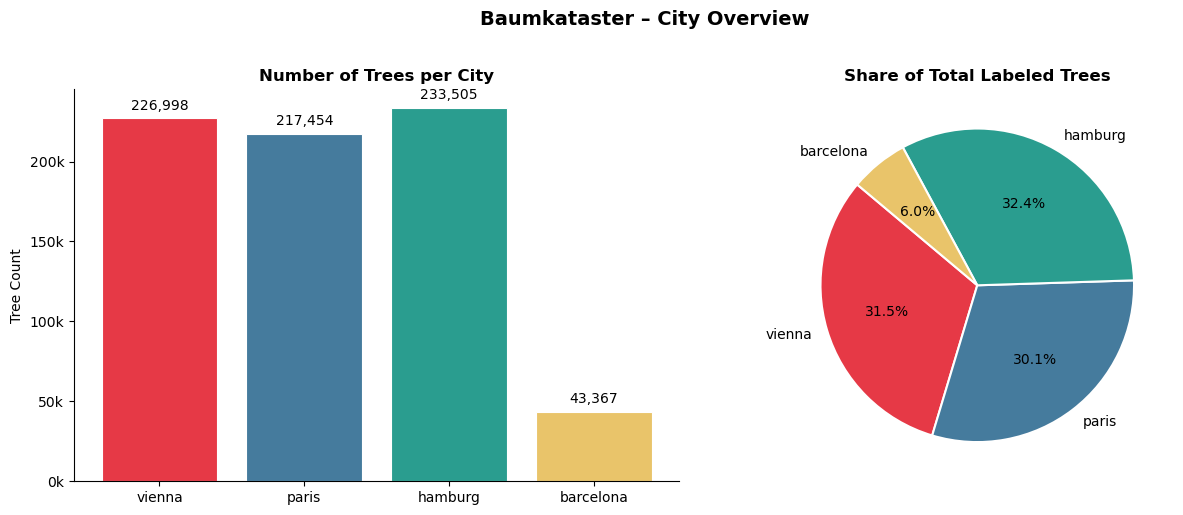

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: tree counts 
ax = axes[0]
counts = {city: len(df) for city, df in bk.items()}
bars = ax.bar(counts.keys(), counts.values(),
              color=[CITY_COLORS[c] for c in counts.keys()], edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}", padding=4, fontsize=10)
ax.set_title("Number of Trees per City", fontweight="bold")
ax.set_ylabel("Tree Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.spines[["top", "right"]].set_visible(False)

# Pie chart: relative shares 
ax = axes[1]
ax.pie(counts.values(), labels=counts.keys(),
       colors=[CITY_COLORS[c] for c in counts.keys()],
       autopct="%1.1f%%", startangle=140,
       wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax.set_title("Share of Total Labeled Trees", fontweight="bold")

plt.suptitle("Baumkataster – City Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Tree size distributions (height, circumference, crown diameter)

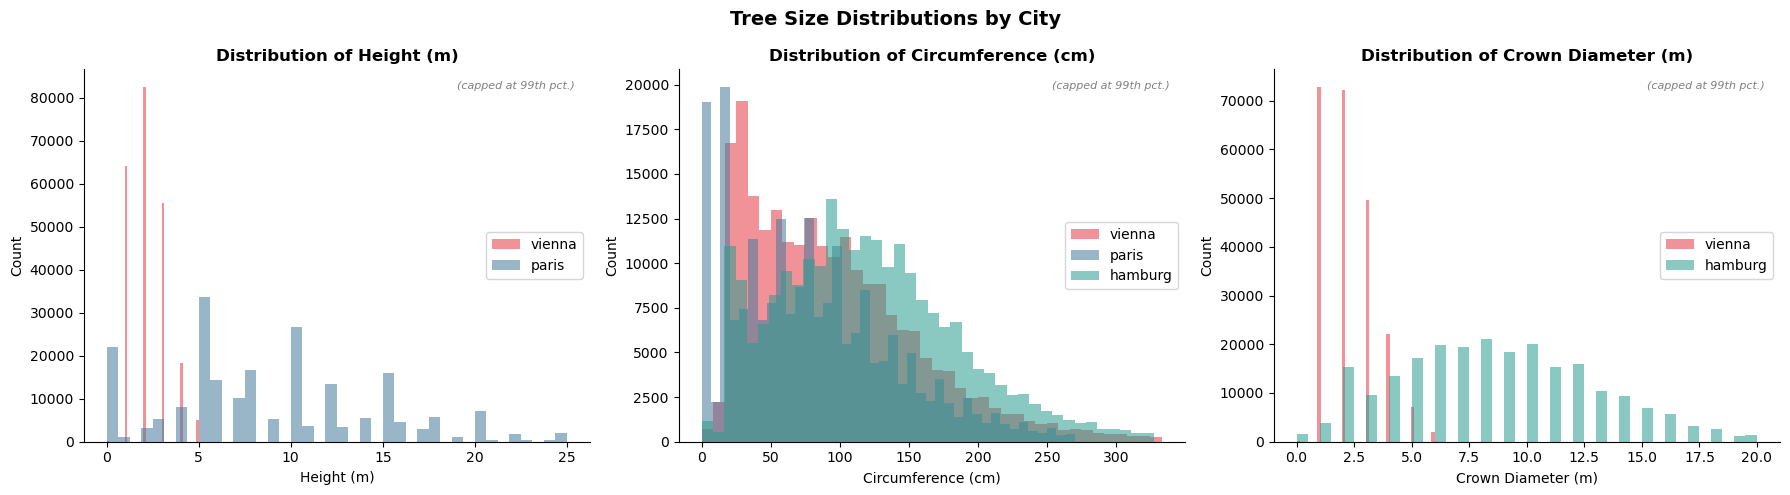

In [11]:
# Cities that have size columns
size_cities = [c for c in ["vienna", "paris", "hamburg"] if c in bk]
size_cols = {"height": "Height (m)", "circumference": "Circumference (cm)", "crown_diameter": "Crown Diameter (m)"}
available_cols = {col: label for col, label in size_cols.items()
                  if any(col in bk[c].columns for c in size_cities)}

fig, axes = plt.subplots(1, len(available_cols), figsize=(6 * len(available_cols), 5))
if len(available_cols) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, available_cols.items()):
    for city in size_cities:
        data = bk[city][col].dropna() if col in bk[city].columns else pd.Series(dtype=float)
        if len(data) > 0:
            # Cap outliers for readability
            cap = data.quantile(0.99)
            ax.hist(data[data <= cap], bins=40, alpha=0.55,
                    color=CITY_COLORS[city], label=city, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}", fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.97, 0.97, "(capped at 99th pct.)",
            ha='right', va='top', transform=ax.transAxes,
            fontsize=8, color='gray', style='italic')

plt.suptitle("Tree Size Distributions by City", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

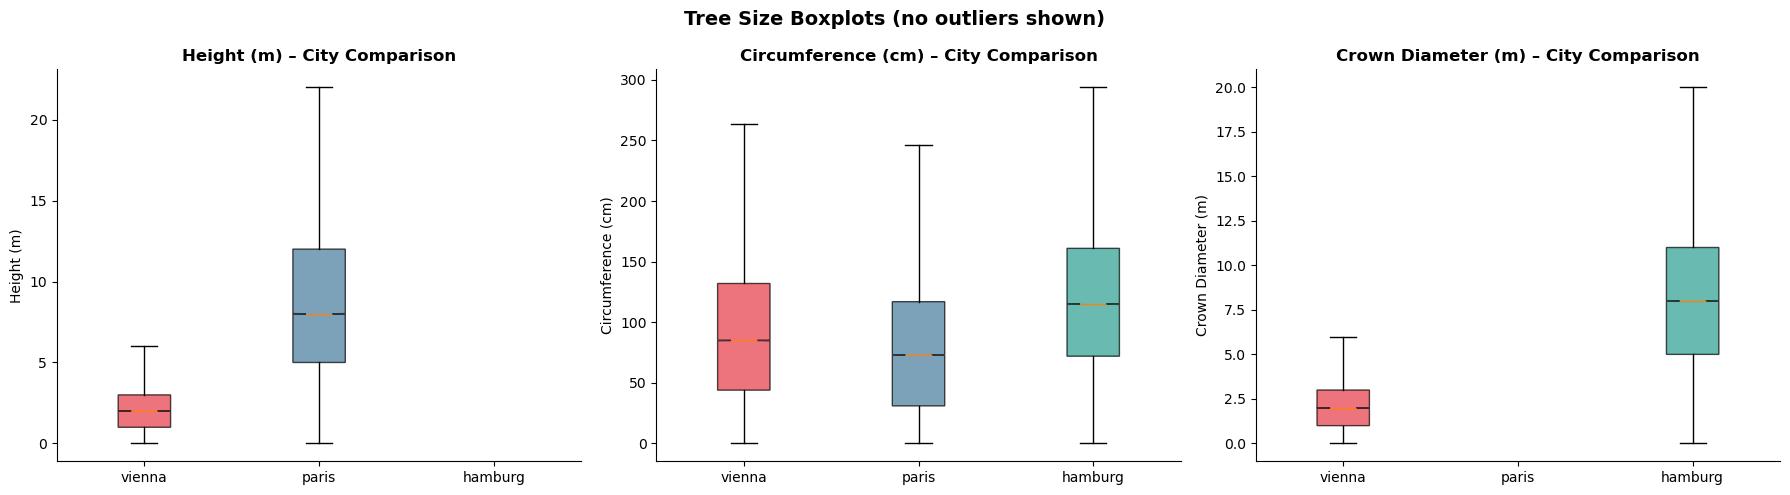

In [12]:
# Boxplots side by side for cleaner city comparison
data_for_box = []
for city in size_cities:
    df = bk[city].copy()
    df["city"] = city
    data_for_box.append(df)
combined = pd.concat(data_for_box, ignore_index=True)

fig, axes = plt.subplots(1, len(available_cols), figsize=(6 * len(available_cols), 5))
if len(available_cols) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, available_cols.items()):
    if col not in combined.columns:
        continue
    plot_data = [combined[combined.city == c][col].dropna() for c in size_cities]
    bp = ax.boxplot(plot_data, patch_artist=True, notch=True,
                    labels=size_cities, showfliers=False)
    for patch, city in zip(bp['boxes'], size_cities):
        patch.set_facecolor(CITY_COLORS[city])
        patch.set_alpha(0.7)
    ax.set_ylabel(label)
    ax.set_title(f"{label} – City Comparison", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Tree Size Boxplots (no outliers shown)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.4 Species analysis

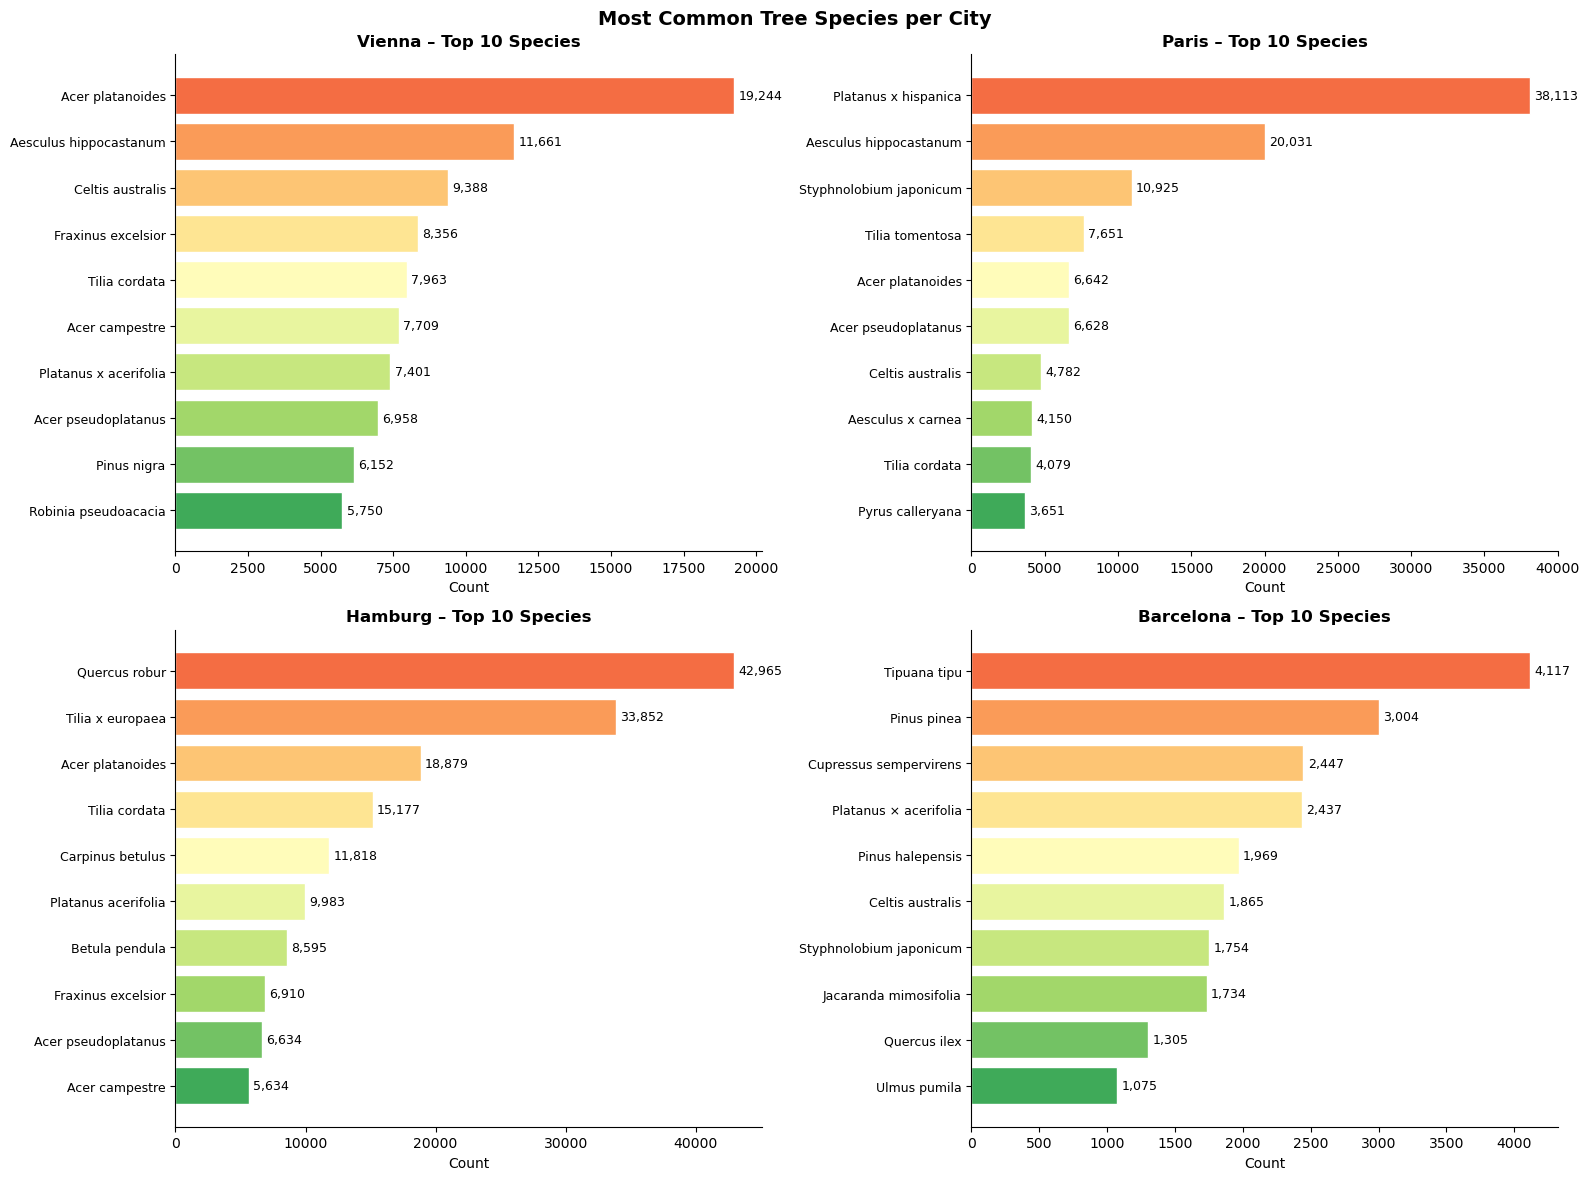

In [13]:
# Top-10 species per city
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, city in zip(axes, CITIES):
    df = bk[city]
    if "species_latin" not in df.columns:
        ax.set_visible(False)
        continue
    top10 = (df["species_latin"]
               .replace("unknown", pd.NA).dropna()
               .value_counts().head(10))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(top10)))
    bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='white')
    ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}", padding=3, fontsize=9)
    ax.set_title(f"{city.capitalize()} – Top 10 Species", fontweight="bold")
    ax.set_xlabel("Count")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle("Most Common Tree Species per City", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
# Species overlap between cities – which species appear in multiple cities?
species_sets = {}
for city in CITIES:
    df = bk[city]
    if "species_latin" in df.columns:
        species_sets[city] = set(df["species_latin"].dropna().unique()) - {"unknown", ""}

print("Species count per city (excluding 'unknown'):")
for city, s in species_sets.items():
    print(f"  {city:12s}: {len(s):>5} unique species")

if len(species_sets) >= 2:
    cities_with_species = list(species_sets.keys())
    shared_all = set.intersection(*species_sets.values())
    print(f"\nSpecies found in ALL cities: {len(shared_all)}")
    if shared_all:
        print("  Top 10:", sorted(list(shared_all))[:10])

Species count per city (excluding 'unknown'):
  vienna      :   670 unique species
  paris       :   996 unique species
  hamburg     :   354 unique species
  barcelona   :   330 unique species

Species found in ALL cities: 86
  Top 10: ['Abies alba', 'Abies pinsapo', 'Acer buergerianum', 'Acer campestre', 'Acer monspessulanum', 'Acer negundo', 'Acer platanoides', 'Acer pseudoplatanus', 'Acer saccharinum', 'Aesculus hippocastanum']


### 2.5 Spatial distribution maps

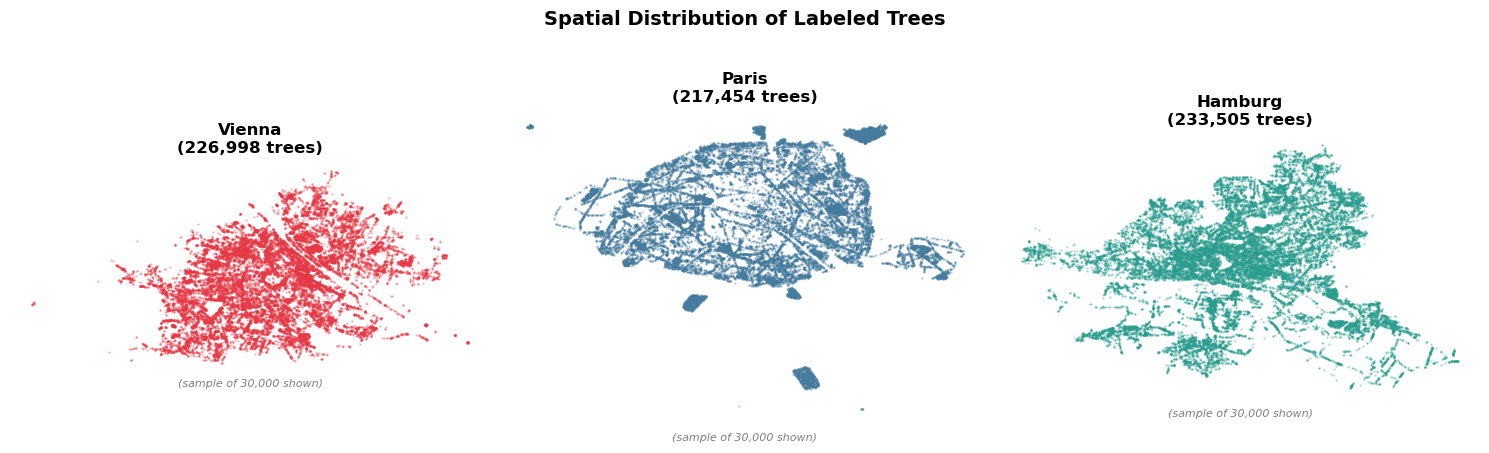

In [17]:
# Spatial scatter plot of tree locations per city
geo_cities = [c for c in CITIES if "geometry" in bk[c].columns]

fig, axes = plt.subplots(1, len(geo_cities), figsize=(5 * len(geo_cities), 5))
if len(geo_cities) == 1:
    axes = [axes]

for ax, city in zip(axes, geo_cities):
    gdf = bk[city]
    # Sample for performance if very large
    sample = gdf.sample(min(len(gdf), 30_000), random_state=42)
    ax.scatter(sample.geometry.x, sample.geometry.y,
               s=0.5, alpha=0.3, color=CITY_COLORS[city], rasterized=True)
    ax.set_title(f"{city.capitalize()}\n({len(gdf):,} trees)", fontweight="bold")
    ax.set_aspect('equal')
    ax.axis('off')
    ax.text(0.5, -0.03, f"(sample of {min(len(gdf), 30_000):,} shown)",
            ha='center', va='top', transform=ax.transAxes,
            fontsize=8, color='gray', style='italic')

plt.suptitle("Spatial Distribution of Labeled Trees", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

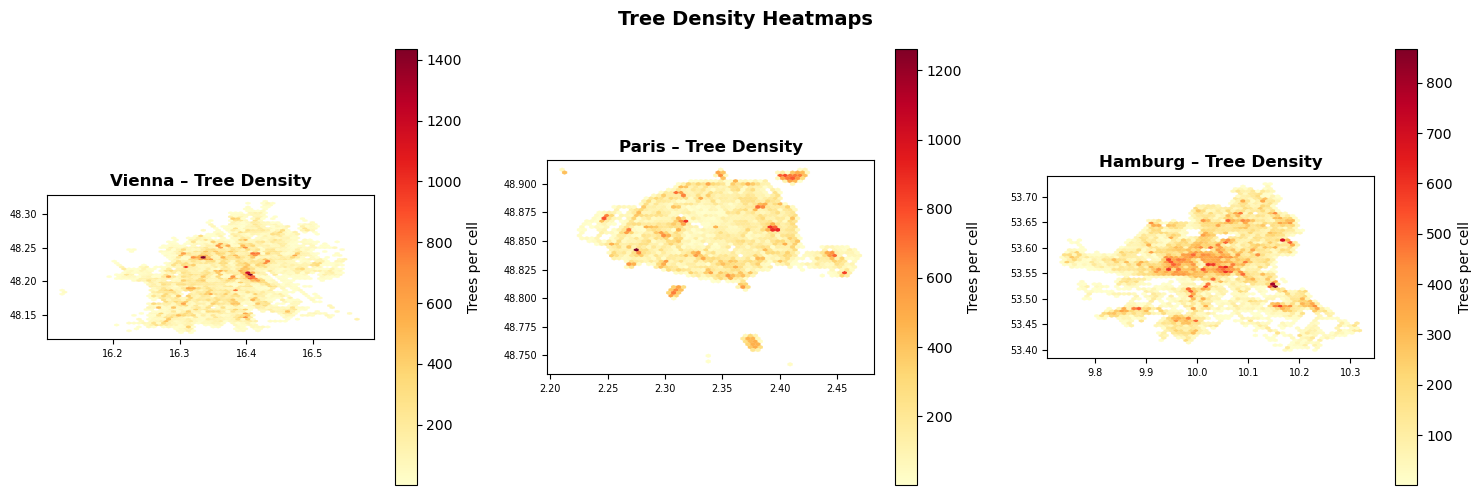

In [18]:
# 2D density (hexbin) map – useful to spot clusters/parks vs. street lines
fig, axes = plt.subplots(1, len(geo_cities), figsize=(5 * len(geo_cities), 5))
if len(geo_cities) == 1:
    axes = [axes]

for ax, city in zip(axes, geo_cities):
    gdf = bk[city]
    x = gdf.geometry.x
    y = gdf.geometry.y
    hb = ax.hexbin(x, y, gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.2)
    plt.colorbar(hb, ax=ax, label='Trees per cell')
    ax.set_title(f"{city.capitalize()} – Tree Density", fontweight="bold")
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

plt.suptitle("Tree Density Heatmaps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Sentinel-2 EDA

### 3.1 Band statistics per city & season

In [22]:
def read_band_stats(tif_path, band_names=BAND_NAMES):
    """Read per-band mean, std, min, max from a GeoTIFF."""
    stats = []
    with rasterio.open(tif_path) as src:
        n_bands = min(src.count, len(band_names))
        for i in range(1, n_bands + 1):
            data = src.read(i).astype(float)
            nodata = src.nodata
            if nodata is not None:
                data = data[data != nodata]
            data = data[np.isfinite(data)]
            stats.append({
                "band": band_names[i - 1],
                "mean": np.mean(data),
                "std": np.std(data),
                "min": np.min(data),
                "max": np.max(data),
                "p5": np.percentile(data, 5),
                "p95": np.percentile(data, 95),
            })
    return pd.DataFrame(stats)

# Collect stats for all available city/season combos
sentinel_stats = []
for city, seasons in sentinel_paths.items():
    for season, path in seasons.items():
        df = read_band_stats(path)
        df["city"] = city
        df["season"] = season
        sentinel_stats.append(df)

if sentinel_stats:
    sentinel_stats_df = pd.concat(sentinel_stats, ignore_index=True)
    print(sentinel_stats_df.pivot_table(index=["city", "season"], columns="band", values="mean").round(4))
else:
    print("No Sentinel files found – check paths above.")

band              B02_blue  B03_green    B04_red    B08_nir     EVI    NDVI  \
city      season                                                              
barcelona apr     776.8378   947.8908  1078.3907  1950.7591  0.9000  0.2807   
          aug     818.1956  1020.3644  1185.4248  2187.8615  0.8557  0.2867   
          nov     554.0079   708.2380   792.4719  1695.3566  0.9689  0.2867   
hamburg   apr     600.2659   786.4967   830.1279  1752.7997  0.8083  0.2949   
          aug     567.1747   752.9619   722.3703  2190.8804  1.2413  0.4179   
          nov     323.1976   545.8062   608.1254  1646.6537  0.7093  0.3469   
paris     apr     699.0298   872.2675   867.7551  1993.0288  1.3363  0.3708   
          aug     723.9907   891.5589   904.9449  2202.5132  1.3314  0.3955   
          nov     597.7392   793.1299   778.4359  2271.4927  1.4568  0.4757   
vienna    apr     537.4027   790.9201   699.8499  2874.3223  1.6667  0.5630   
          aug     549.8148   752.3749   720.0474  29

### 3.2 Vegetation index distributions (NDVI, EVI, SAVI)

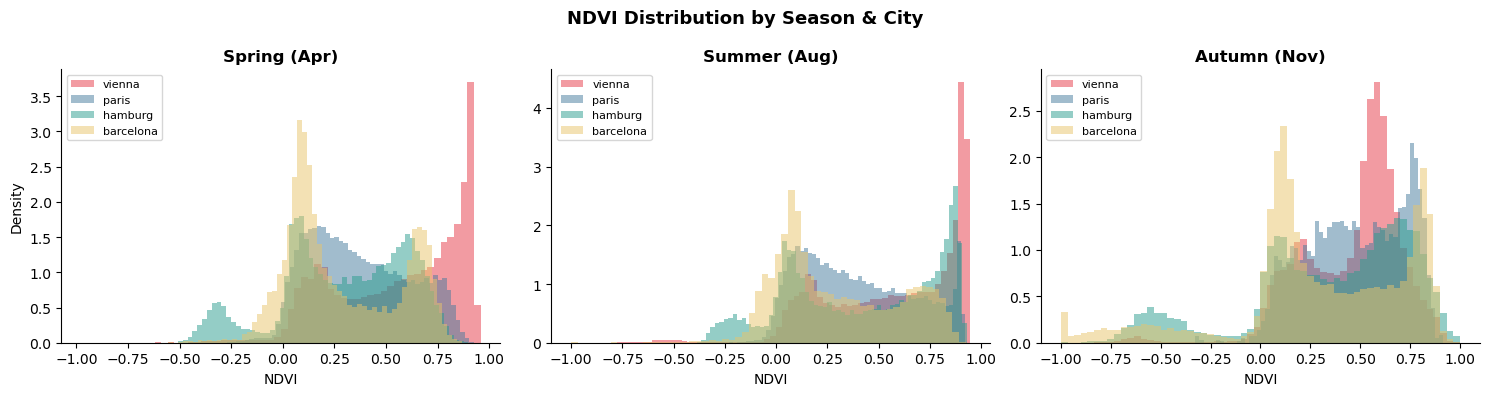

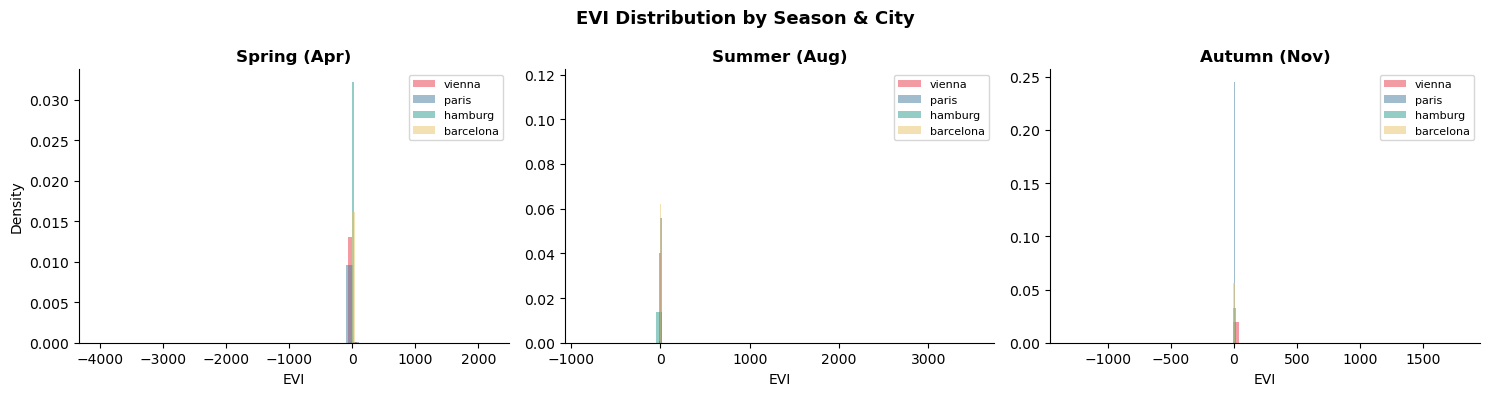

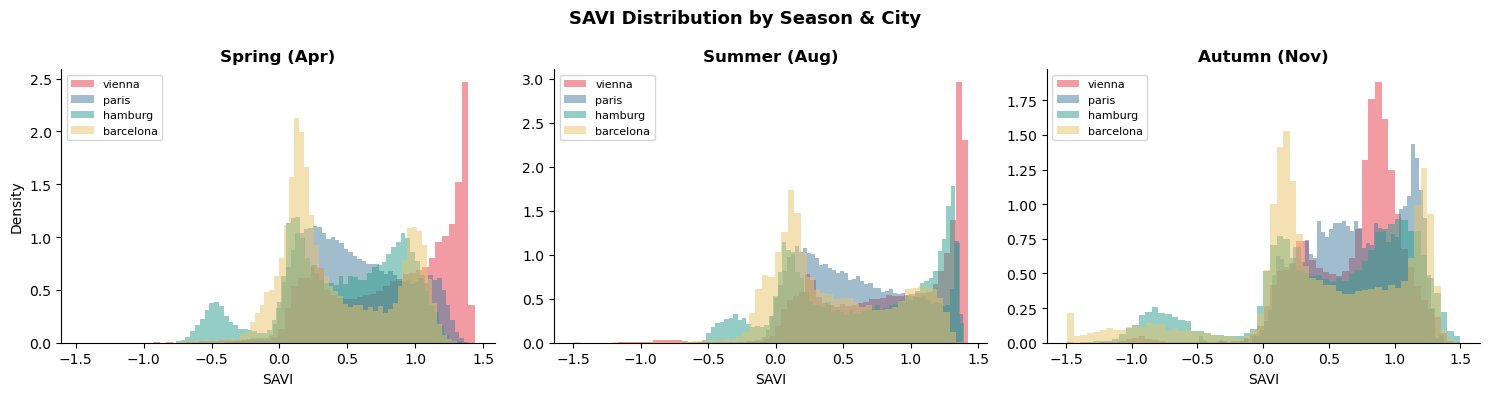

In [23]:
def read_index_values(tif_path, band_idx, sample_frac=0.01):
    """Read a flattened sample of pixel values from one band."""
    with rasterio.open(tif_path) as src:
        data = src.read(band_idx).astype(float).flatten()
        nodata = src.nodata
        if nodata is not None:
            data = data[data != nodata]
        data = data[np.isfinite(data)]
        # Random subsample to avoid memory issues
        rng = np.random.default_rng(42)
        n = max(1, int(len(data) * sample_frac))
        return rng.choice(data, size=n, replace=False)

# NDVI, EVI, SAVI assumed to be bands 5, 6, 7 (index 5,6,7 → 1-indexed: 5,6,7)
INDEX_BAND = {"NDVI": 5, "EVI": 6, "SAVI": 7}

for idx_name, band_idx in INDEX_BAND.items():
    fig, axes = plt.subplots(1, len(SEASONS), figsize=(5 * len(SEASONS), 4), sharey=False)
    if len(SEASONS) == 1:
        axes = [axes]

    for ax, season in zip(axes, SEASONS):
        for city in CITIES:
            path = sentinel_paths.get(city, {}).get(season)
            if path is None:
                continue
            vals = read_index_values(path, band_idx)
            ax.hist(vals, bins=60, alpha=0.5, label=city, color=CITY_COLORS[city],
                    density=True, edgecolor='none')
        ax.set_title(f"{SEASON_LABELS[season]}", fontweight="bold")
        ax.set_xlabel(idx_name)
        ax.set_ylabel("Density" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"{idx_name} Distribution by Season & City", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

### 3.3 Seasonal variation of mean NDVI per city

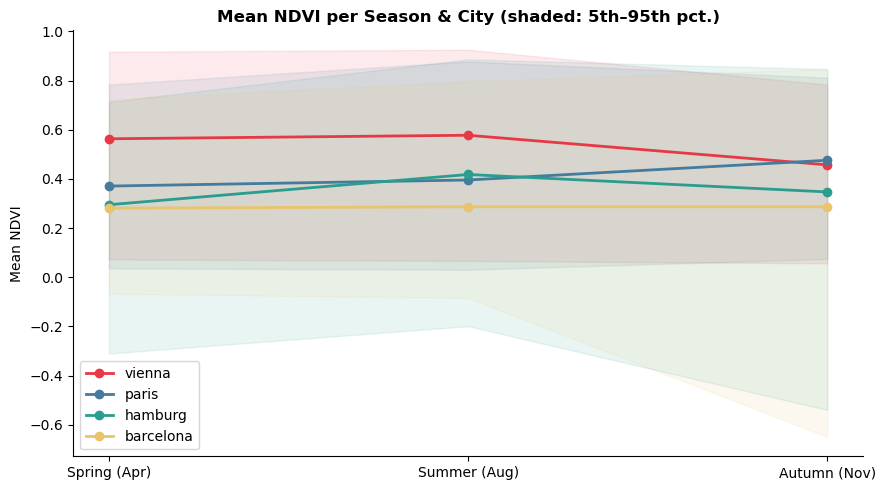

In [24]:
if sentinel_stats:
    ndvi_df = sentinel_stats_df[sentinel_stats_df["band"] == "NDVI"].copy()
    ndvi_df["season_label"] = ndvi_df["season"].map(SEASON_LABELS)
    season_order = [SEASON_LABELS[s] for s in SEASONS]

    fig, ax = plt.subplots(figsize=(9, 5))
    for city in ndvi_df["city"].unique():
        subset = ndvi_df[ndvi_df["city"] == city].set_index("season_label").reindex(season_order)
        ax.plot(season_order, subset["mean"], marker='o', linewidth=2,
                color=CITY_COLORS.get(city, 'gray'), label=city)
        ax.fill_between(season_order, subset["p5"], subset["p95"],
                        alpha=0.1, color=CITY_COLORS.get(city, 'gray'))

    ax.set_title("Mean NDVI per Season & City (shaded: 5th–95th pct.)", fontweight="bold")
    ax.set_ylabel("Mean NDVI")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### 3.4 False-color RGB composite (NIR/Red/Green) – visual sanity check

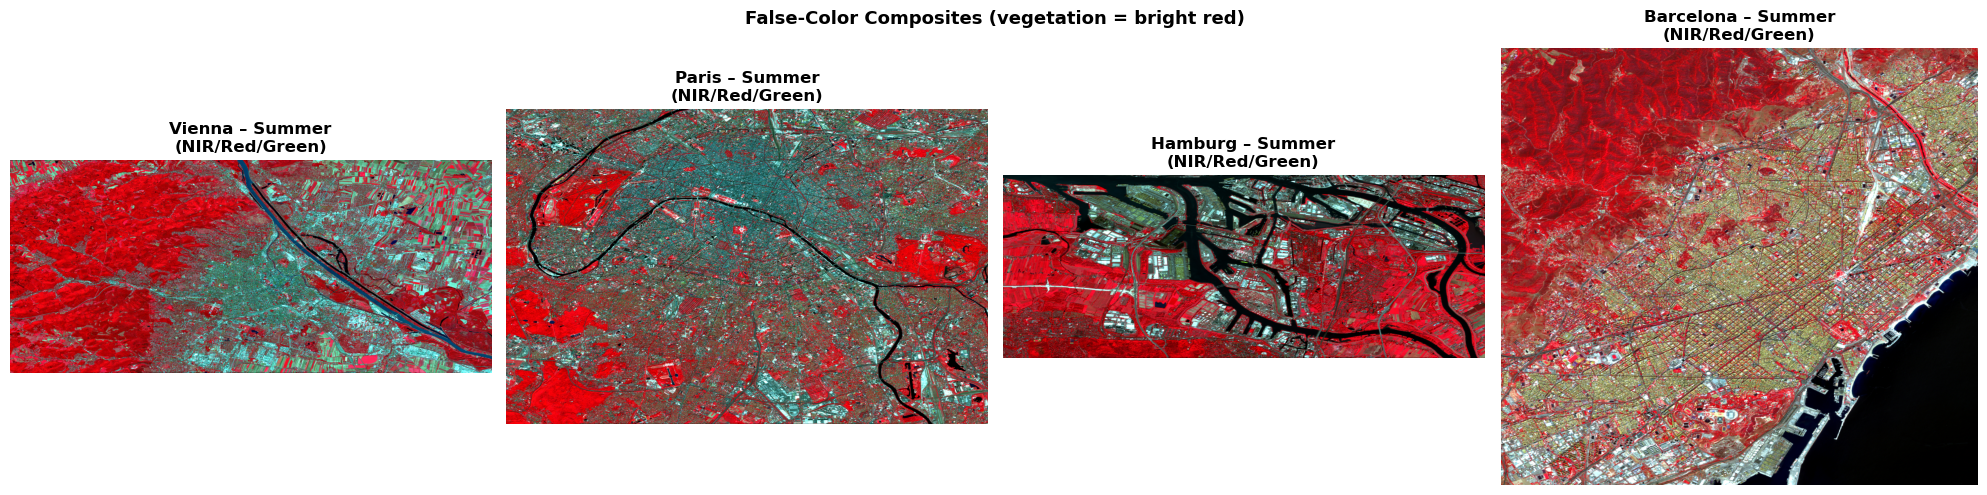

In [26]:
# NIR → R channel, Red → G channel, Green → B channel
# Trees/vegetation appear bright red in this view

def false_color(tif_path, nir_idx=4, red_idx=3, green_idx=2):
    """Return an (H, W, 3) uint8 false-color image."""
    with rasterio.open(tif_path) as src:
        def norm(band_idx):
            b = src.read(band_idx).astype(float)
            p2, p98 = np.percentile(b[b > 0], [2, 98]) if (b > 0).any() else (0, 1)
            b = np.clip((b - p2) / (p98 - p2 + 1e-9), 0, 1)
            return (b * 255).astype(np.uint8)
        return np.stack([norm(nir_idx), norm(red_idx), norm(green_idx)], axis=-1)

sample_season = "aug"  # summer = peak vegetation
available = [(city, sentinel_paths[city][sample_season])
             for city in CITIES if sample_season in sentinel_paths.get(city, {})]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
    for ax, (city, path) in zip(axes, available):
        img = false_color(path)
        ax.imshow(img)
        ax.set_title(f"{city.capitalize()} – Summer\n(NIR/Red/Green)", fontweight="bold")
        ax.axis('off')
    plt.suptitle("False-Color Composites (vegetation = bright red)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 4. OSM EDA

### 4.1 Feature class distributions

In [27]:
# fclass value counts for roads and landuse per city
for layer in ["roads", "landuse"]:
    print(f"\n{'='*60}\n{layer.upper()} – fclass breakdown")
    rows = []
    for city in CITIES:
        if city in osm and layer in osm[city]:
            vc = osm[city][layer]["fclass"].value_counts()
            df_vc = vc.reset_index()
            df_vc.columns = ["fclass", "count"]
            df_vc["city"] = city
            rows.append(df_vc)
    if rows:
        combined_vc = pd.concat(rows)
        pivot = combined_vc.pivot_table(index="fclass", columns="city", values="count", fill_value=0)
        display(pivot.sort_values(pivot.columns[0], ascending=False).head(20))


ROADS – fclass breakdown


city,barcelona,hamburg,paris,vienna
fclass,,,,
footway,58675.0,6435.0,155506.0,72133.0
residential,7885.0,1551.0,22617.0,17978.0
cycleway,4850.0,1126.0,9045.0,6721.0
service,4746.0,7990.0,31333.0,23428.0
steps,4614.0,977.0,12092.0,7404.0
pedestrian,3532.0,127.0,5852.0,1621.0
tertiary,2906.0,544.0,4234.0,3494.0
living_street,2706.0,113.0,1792.0,906.0
secondary,1911.0,1100.0,6168.0,4125.0



LANDUSE – fclass breakdown


city,barcelona,hamburg,paris,vienna
fclass,,,,
grass,2562.0,844.0,16947.0,19554.0
park,773.0,127.0,1772.0,1212.0
heath,592.0,2.0,23.0,67.0
residential,462.0,310.0,452.0,1268.0
scrub,438.0,508.0,3774.0,1759.0
meadow,300.0,636.0,357.0,2137.0
forest,257.0,415.0,2376.0,2630.0
industrial,150.0,179.0,223.0,422.0
allotments,93.0,67.0,209.0,726.0


### 4.2 Landuse breakdown per city

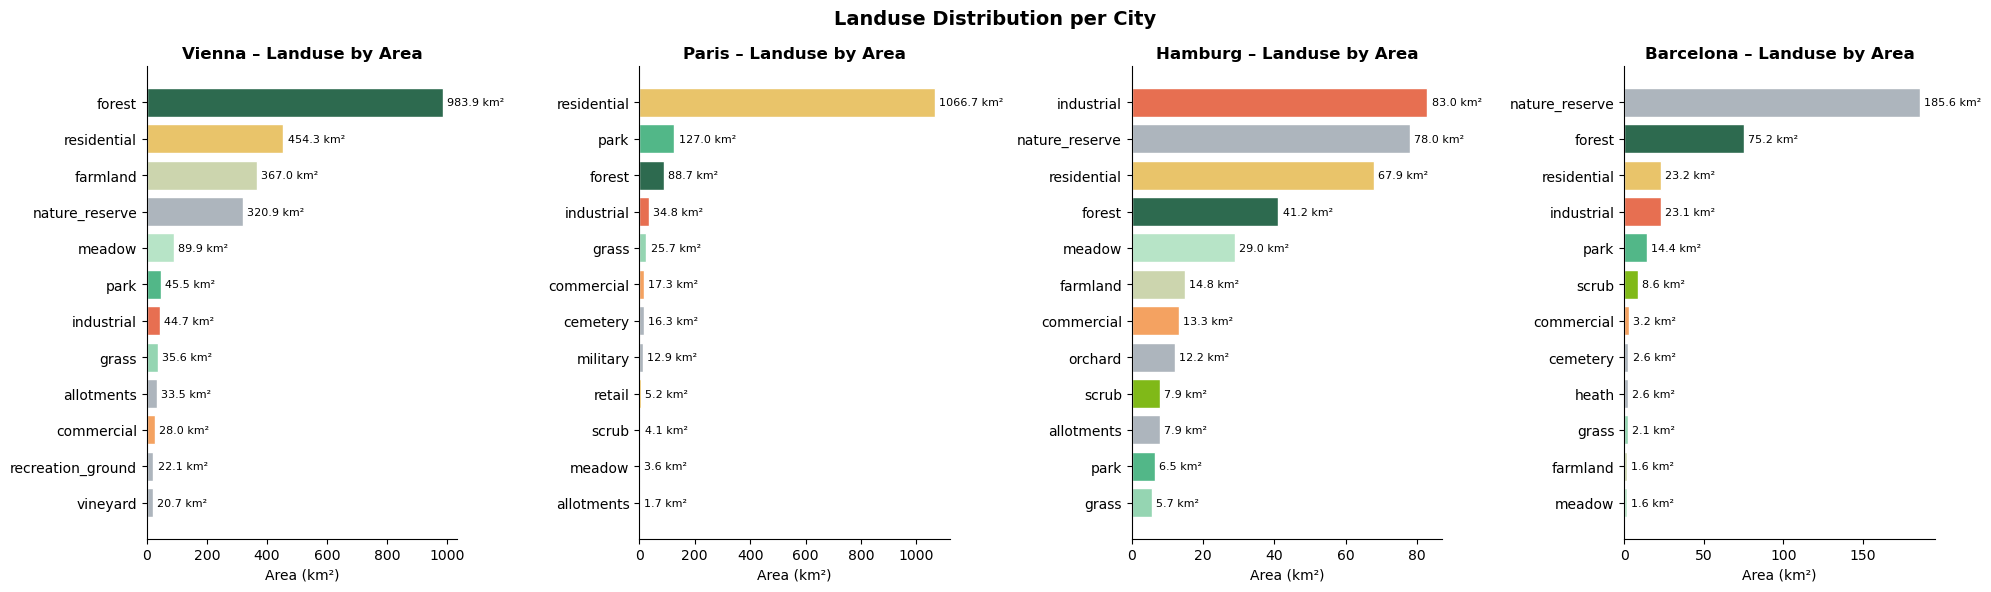

In [28]:
cities_with_landuse = [c for c in CITIES if c in osm and "landuse" in osm[c]]

fig, axes = plt.subplots(1, len(cities_with_landuse), figsize=(5 * len(cities_with_landuse), 6))
if len(cities_with_landuse) == 1:
    axes = [axes]

# Color palette for landuse classes
LANDUSE_COLORS = {
    "forest": "#2d6a4f", "park": "#52b788", "grass": "#95d5b2",
    "meadow": "#b7e4c7", "residential": "#e9c46a",
    "commercial": "#f4a261", "industrial": "#e76f51",
    "farmland": "#ccd5ae", "scrub": "#80b918",
    "retail": "#f9c74f", "cemetery": "#adb5bd",
}

for ax, city in zip(axes, cities_with_landuse):
    gdf = osm[city]["landuse"].copy()
    # Area in km²
    gdf_proj = gdf.to_crs(epsg=3857)  # metres
    gdf["area_km2"] = gdf_proj.geometry.area / 1e6
    area_by_class = gdf.groupby("fclass")["area_km2"].sum().sort_values(ascending=False).head(12)
    colors = [LANDUSE_COLORS.get(c, "#adb5bd") for c in area_by_class.index]
    bars = ax.barh(area_by_class.index[::-1], area_by_class.values[::-1],
                   color=colors[::-1], edgecolor='white')
    ax.bar_label(bars, fmt=lambda v: f"{v:.1f} km²", padding=3, fontsize=8)
    ax.set_title(f"{city.capitalize()} – Landuse by Area", fontweight="bold")
    ax.set_xlabel("Area (km²)")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Landuse Distribution per City", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.3 Road type distribution

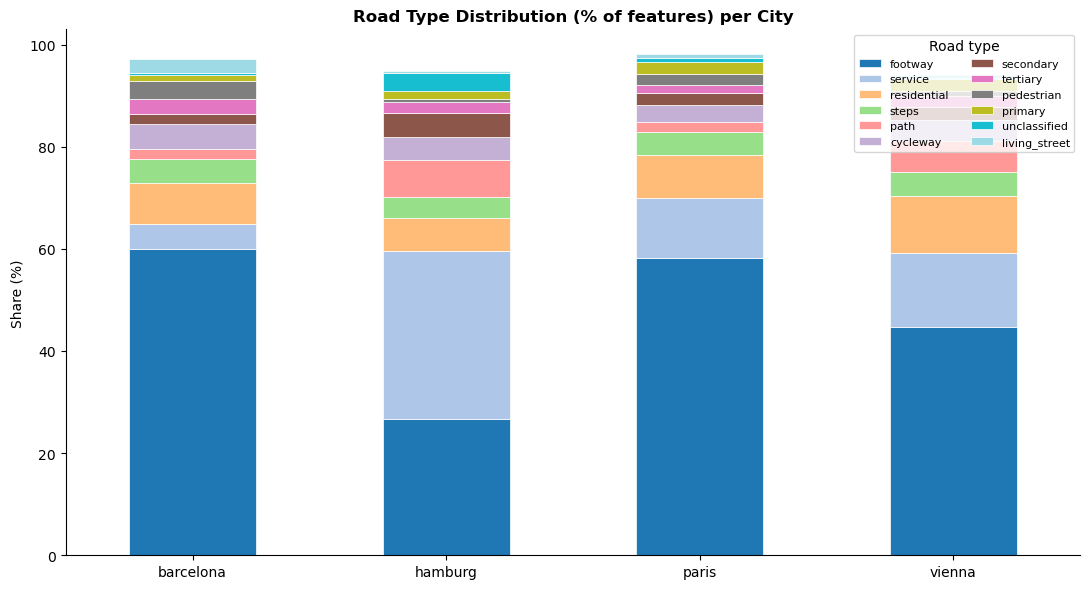

In [29]:
cities_with_roads = [c for c in CITIES if c in osm and "roads" in osm[c]]

# Stacked bar: road type share per city
road_rows = []
for city in cities_with_roads:
    vc = osm[city]["roads"]["fclass"].value_counts(normalize=True) * 100
    df_vc = vc.reset_index()
    df_vc.columns = ["fclass", "pct"]
    df_vc["city"] = city
    road_rows.append(df_vc)

if road_rows:
    road_df = pd.concat(road_rows)
    pivot = road_df.pivot_table(index="fclass", columns="city", values="pct", fill_value=0)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).head(12).index]

    fig, ax = plt.subplots(figsize=(11, 6))
    pivot.T.plot(kind='bar', stacked=True, ax=ax,
                 colormap='tab20', edgecolor='white', linewidth=0.5)
    ax.set_title("Road Type Distribution (% of features) per City", fontweight="bold")
    ax.set_ylabel("Share (%)")
    ax.set_xlabel("")
    ax.legend(loc='upper right', ncol=2, fontsize=8, title='Road type')
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

---
## 5. Cross-dataset: Trees vs. Urban Context

### 5.1 Fraction of trees inside green landuse zones (park, forest, grass)

vienna: 52.3% of sampled trees fall inside a green landuse zone
paris: 42.2% of sampled trees fall inside a green landuse zone
hamburg: 2.6% of sampled trees fall inside a green landuse zone


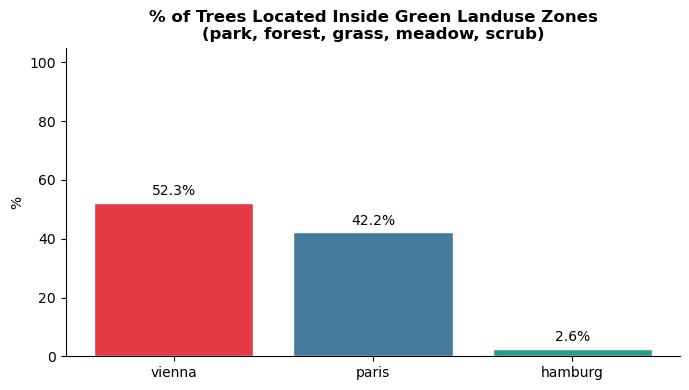

In [30]:
GREEN_CLASSES = {"park", "forest", "grass", "meadow", "scrub"}

geo_with_osm = [c for c in CITIES if c in osm and "landuse" in osm[c] and "geometry" in bk[c].columns]

results = []
for city in geo_with_osm:
    trees = bk[city].to_crs(epsg=3857).copy()
    landuse = osm[city]["landuse"].to_crs(epsg=3857)
    green = landuse[landuse["fclass"].isin(GREEN_CLASSES)].copy()
    
    # Sample for performance
    sample = trees.sample(min(len(trees), 20_000), random_state=42)
    joined = gpd.sjoin(sample, green[["fclass", "geometry"]], how="left", predicate="within")
    in_green = joined["fclass"].notna().mean() * 100
    results.append({"city": city, "pct_trees_in_green_zone": round(in_green, 1),
                    "n_trees_sample": len(sample)})
    print(f"{city}: {in_green:.1f}% of sampled trees fall inside a green landuse zone")

if results:
    res_df = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(res_df["city"], res_df["pct_trees_in_green_zone"],
                  color=[CITY_COLORS[c] for c in res_df["city"]], edgecolor='white')
    ax.bar_label(bars, fmt=lambda v: f"{v:.1f}%", padding=3)
    ax.set_title("% of Trees Located Inside Green Landuse Zones\n(park, forest, grass, meadow, scrub)",
                 fontweight="bold")
    ax.set_ylabel("%")
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### 5.2 NDVI at tree locations vs. random background (Vienna, summer)

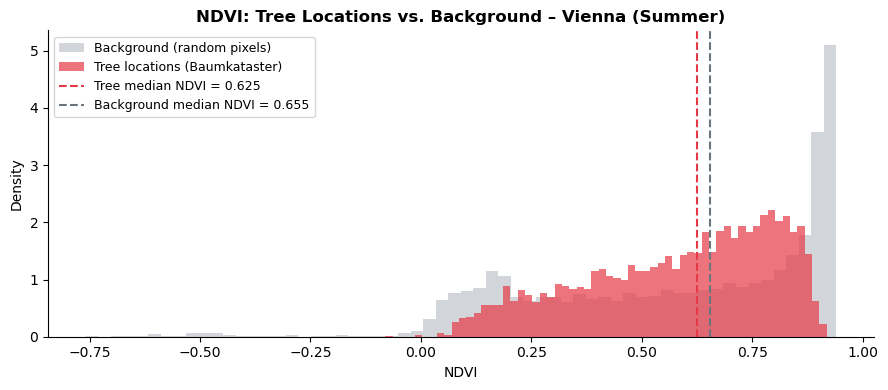

In [31]:
# Sample NDVI values at tree point locations vs. random non-tree pixels

def sample_ndvi_at_points(tif_path, gdf_points, ndvi_band_idx=5, n_random=5000, seed=42):
    """Returns arrays: ndvi_at_trees, ndvi_random_background."""
    with rasterio.open(tif_path) as src:
        ndvi = src.read(ndvi_band_idx).astype(float)
        transform = src.transform
        nodata = src.nodata
        
        # Sample at tree locations
        pts = gdf_points.to_crs(src.crs)
        sample = pts.sample(min(len(pts), n_random), random_state=seed)
        rows, cols = rasterio.transform.rowcol(transform, sample.geometry.x.values, sample.geometry.y.values)
        h, w = ndvi.shape
        valid = (np.array(rows) >= 0) & (np.array(rows) < h) & (np.array(cols) >= 0) & (np.array(cols) < w)
        tree_vals = ndvi[np.array(rows)[valid], np.array(cols)[valid]]
        if nodata:
            tree_vals = tree_vals[tree_vals != nodata]
        tree_vals = tree_vals[np.isfinite(tree_vals)]
        
        # Random background
        rng = np.random.default_rng(seed)
        flat = ndvi.flatten()
        if nodata:
            flat = flat[flat != nodata]
        flat = flat[np.isfinite(flat)]
        bg_vals = rng.choice(flat, size=min(n_random, len(flat)), replace=False)
        
    return tree_vals, bg_vals

city_check = "vienna"
season_check = "aug"

if (city_check in sentinel_paths and season_check in sentinel_paths[city_check]
        and "geometry" in bk[city_check].columns):
    tif = sentinel_paths[city_check][season_check]
    tree_ndvi, bg_ndvi = sample_ndvi_at_points(tif, bk[city_check])

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(bg_ndvi, bins=60, alpha=0.55, density=True, color='#adb5bd',
            label='Background (random pixels)', edgecolor='none')
    ax.hist(tree_ndvi, bins=60, alpha=0.7, density=True, color=CITY_COLORS[city_check],
            label='Tree locations (Baumkataster)', edgecolor='none')
    ax.axvline(np.median(tree_ndvi), color=CITY_COLORS[city_check], linestyle='--',
               linewidth=1.5, label=f'Tree median NDVI = {np.median(tree_ndvi):.3f}')
    ax.axvline(np.median(bg_ndvi), color='#6c757d', linestyle='--',
               linewidth=1.5, label=f'Background median NDVI = {np.median(bg_ndvi):.3f}')
    ax.set_xlabel('NDVI')
    ax.set_ylabel('Density')
    ax.set_title(f'NDVI: Tree Locations vs. Background – {city_check.capitalize()} (Summer)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print(f"Skipping NDVI cross-check – {city_check}/{season_check} Sentinel file or geometry not available.")

### 5.3 Correlation heatmap of tree attributes (Vienna)

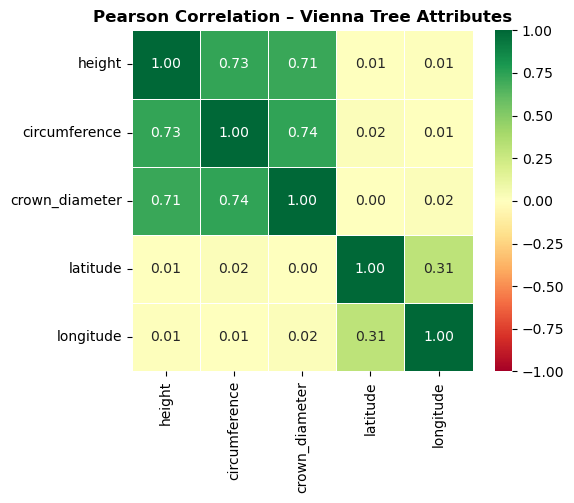

In [32]:
numeric_cols = [c for c in ["height", "circumference", "crown_diameter", "latitude", "longitude"]
                if c in bk["vienna"].columns]
corr = bk["vienna"][numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Pearson Correlation – Vienna Tree Attributes", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Summary & Notes for Modelling

### Baumkataster

Vienna (227k), Paris (217k), and Hamburg (234k) are roughly balanced in size and suitable as training cities. Barcelona (43k) has no size attributes and no geometry column — still useful as point locations for a generalization test.

Vienna's `height` column stores ordinal category codes (1–8), not actual metres — the mean of 2.21 confirms this. Paris `height` (mean 8.99m) is real metres. Do not use Vienna height as a continuous feature; either treat it as ordinal or drop it.

**Key finding — street trees vs. park trees:** 52% of Vienna trees and 42% of Paris trees fall inside green landuse zones, but only 2.6% of Hamburg trees do. Hamburg is almost entirely street-planted. This means the model cannot rely on "park = trees" as a shortcut — it needs to learn both patterns.

86 species appear across all four cities, dominated by *Acer* and *Aesculus* genera. Species is not a model input but useful context for understanding crown size variation. Circumference and crown_diameter correlate strongly where both are available — no need to use both as separate features if dimensionality is a concern.

---

### Sentinel-2

All 12 city/season combinations loaded successfully. Key statistics:

- NDVI peaks in summer (August) for all cities, especially Hamburg (0.42) vs. spring/autumn (~0.29). Summer imagery carries the strongest vegetation signal.
- Barcelona and Vienna show lower summer NDVI than Hamburg and Paris, likely reflecting drier conditions and more impervious surface coverage.
- **Data quality EVI scaling:** EVI exceeds 1.0 for cities in summer (e.g. Hamburg/Vienna aug: 1.24), which is impossible since EVI is bounded between -1 and 1. Could be a systematic issue across all cities and seasons, not isolated to one file.

---

### OSM

Roads are dominated by `footway`, `service`, and `residential` across all cities. For masking purposes, consider dropping `footway`, `path`, `steps`, and `track` — these are pedestrian routes that frequently run through parks alongside trees and would create false negatives if used as hard "no tree" masks.

`grass` is the dominant landuse class by feature count in Vienna and Paris. `forest` and `park` are relatively rare by count but large by area. Hamburg's OSM data is noticeably sparser (24k road features vs. 161k for Vienna) — sanity-check that the Hamburg OSM clip was applied correctly.

Buildings are reliable negative labels: no trees grow on rooftops. Building footprints can be used to mask out pixels during training label generation.

---